# 01 - Data Loading & Exploration
Load raw spectral, meteorological, and static feature data.

In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.utils import setup_logging, ensure_dir
from src.data_loading import (
    load_spectral, load_meteo, load_static_features,
    load_elevation, merge_all_static,
)

logger = setup_logging()
config = load_config()
ensure_dir(config['data']['output_dir'])

print("Configuration loaded successfully")

Configuration loaded successfully


## 1. Load Spectral Data
12 monthly Sentinel-2 CSVs (Jul 2024 - Jun 2025)

In [9]:
spectral_df = load_spectral(config['data']['spectral_dir'])

print(f"Shape: {spectral_df.shape}")
print(f"Fields: {spectral_df['field_key'].nunique()}")
print(f"Date range: {spectral_df['date'].min()} to {spectral_df['date'].max()}")
print(f"Columns: {list(spectral_df.columns)}")
spectral_df.head()

23:34:06 | INFO    | Spectral data loaded: 240 fields, 115 unique dates, 27600 rows, 12 files


Shape: (27600, 44)
Fields: 240
Date range: 2024-07-03 00:00:00 to 2025-06-28 00:00:00
Columns: ['field_key', 'date', 'NDVI', 'EVI2', 'GNDVI', 'NDRE', 'CIre', 'IRECI', 'NDWI', 'MSI', 'GCVI', 'MNDWI', 'NBR', 'NBR2', 'GVI', 'DGCI', 'NDSWIR1RedEdge1', 'TCARI', 'OSAVI', 'CCCI', 'mARI', 'ExG', 'DBSI', 'SMMI', 'MIRBI', 'CVI', 'S2REP', 'PVI', 'MTCI', 'SAVI', 'NDRE2', 'RE_ratio', 'PSRI', 'LSWI', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']


,field_key,date,NDVI,EVI2,GNDVI,NDRE,CIre,IRECI,NDWI,MSI,...,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
0,1,2024-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-07-05,0.213335,0.143113,0.347678,0.160475,0.388208,0.101276,-0.238388,1.637352,...,0.104964,0.137646,0.184397,0.224654,0.249209,0.273166,0.282651,0.309646,0.458073,0.373621
2,1,2024-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024-07-10,0.206382,0.154051,0.330406,0.152115,0.365505,0.120031,-0.228525,1.601456,...,0.132420,0.170916,0.223821,0.270322,0.298454,0.329422,0.338493,0.366450,0.539664,0.490512
4,1,2024-07-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Load Meteorological Data

In [10]:
meteo_df = load_meteo(config['data']['meteo_dir'])

print(f"Shape: {meteo_df.shape}")
print(f"Fields: {meteo_df['field_key'].nunique()}")
print(f"Date range: {meteo_df['date'].min()} to {meteo_df['date'].max()}")
meteo_df.head()

23:34:07 | INFO    | Meteo data loaded: 240 fields, 365 unique dates, 87600 rows, 12 files


Shape: (87600, 9)
Fields: 240
Date range: 2024-07-01 00:00:00 to 2025-06-30 00:00:00


,field_key,date,t2m_mean,t2m_min,t2m_max,precip,pet,dewpoint,ssrd_MJm2
0,1,2024-07-01,27.602059,22.570398,36.000177,0.114908,11.492200,19.160172,27.988876
1,1,2024-07-02,30.747589,27.655862,34.567682,0.783265,14.276609,16.575178,24.620536
2,1,2024-07-03,24.453334,20.924661,30.777887,14.321595,5.389251,20.074489,15.951580
3,1,2024-07-04,23.777571,19.679666,28.499719,0.339526,7.513851,18.756272,23.516400
4,1,2024-07-05,22.780328,16.491586,27.651361,0.077826,7.136002,13.973553,25.839900


## 3. Load Static Features

In [11]:
static_df, protein_df = load_static_features(
    config['data']['static_features_path'],
    soil_columns=config['soil']['columns'],
    static_columns=config['soil'].get('static_columns', []),
)

elevation_df = load_elevation(
    config['data']['field_elevation_path'],
    config['data'].get('sample_elevation_path'),
)

print(f"Static features: {static_df.shape}")
print(f"Protein target: {protein_df.shape}")
print(f"Elevation data: {elevation_df.shape}")

23:34:08 | INFO    | Static features: 240 fields, 48 columns (soil=43, static=1, location=4)
23:34:08 | INFO    | Protein target: 240 fields with valid protein_pct
23:34:08 | INFO    | Elevation data: 240 fields, 15 columns


Static features: (240, 50)
Protein target: (240, 2)
Elevation data: (240, 16)


In [12]:
all_static = merge_all_static(static_df, protein_df, elevation_df)
print(f"Merged static: {all_static.shape}")
all_static.head()

23:34:09 | INFO    | Merged static features: 240 fields, 66 columns


Merged static: (240, 66)


,field_key,soil_awc_total,soil_clay_ratio,soil_om_depth_decay,soil_sr_awc_profile,soil_sr_ksat_profile,soil_sr_paw_total_mm,soil_sub_awc_mm,soil_sub_awc_vol,soil_sub_bd,...,elev_min,elev_max,elev_p10,elev_p25,elev_p75,elev_p90,slope_std,slope_min,slope_max,aspect_std
0,gmi_201724000625366,0.12534,1.342857,0.630649,0.176054,1.961044,176.054259,82.339623,0.117628,1.644714,...,743,749,745.0,745.0,747.0,747.0,0.988376,0,5,97.967162
1,gmi_201724000625589,0.13190,1.250395,0.624798,0.176146,1.915328,176.145723,90.110000,0.128729,1.638429,...,733,749,738.0,739.0,743.0,745.0,1.079917,0,5,86.780282
2,gmi_201724000625594,0.13190,1.250395,0.624798,0.176146,1.915328,176.145723,90.110000,0.128729,1.638429,...,741,751,743.0,744.0,747.0,748.0,1.004228,0,5,85.594719
3,gmi_201724000625740,0.13190,1.250395,0.624798,0.176146,1.915328,176.145723,90.110000,0.128729,1.638429,...,725,745,730.0,733.0,737.0,739.0,1.239431,0,7,94.342914
4,gmi_201724000625889,0.12534,1.342857,0.630649,0.176054,1.961044,176.054259,82.339623,0.117628,1.644714,...,762,781,769.0,771.0,777.0,778.0,1.273310,0,8,107.500423


## 4. Exploratory Data Analysis

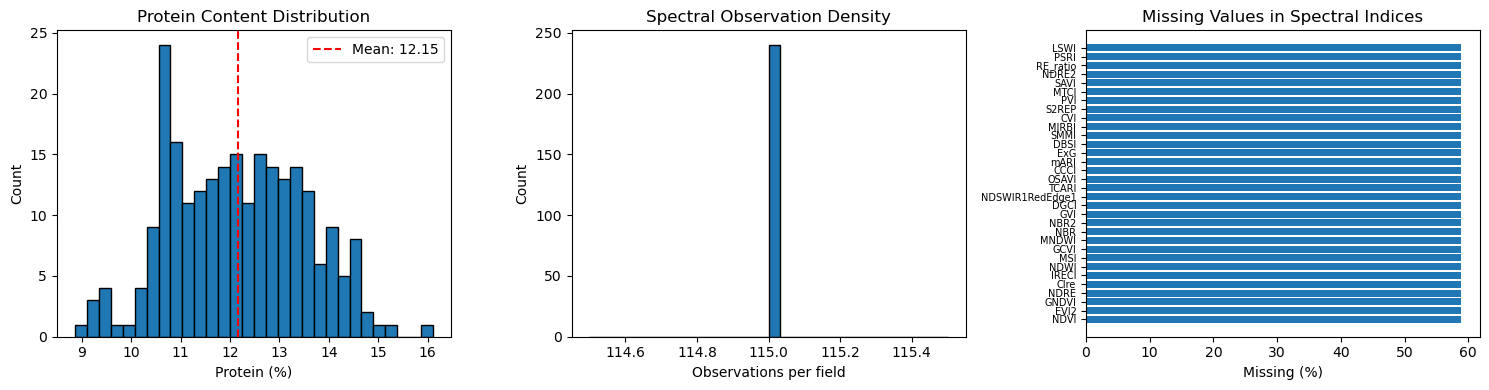

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Protein distribution
axes[0].hist(protein_df['protein_pct'].dropna(), bins=30, edgecolor='black')
axes[0].set_xlabel('Protein (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Protein Content Distribution')
axes[0].axvline(protein_df['protein_pct'].mean(), color='red', linestyle='--', label=f"Mean: {protein_df['protein_pct'].mean():.2f}")
axes[0].legend()

# Temporal coverage - spectral
obs_per_field = spectral_df.groupby('field_key')['date'].count()
axes[1].hist(obs_per_field, bins=30, edgecolor='black')
axes[1].set_xlabel('Observations per field')
axes[1].set_ylabel('Count')
axes[1].set_title('Spectral Observation Density')

# Missing values in spectral
missing_pct = spectral_df[config['spectral']['precomputed_indices']].isna().mean() * 100
axes[2].barh(range(len(missing_pct)), missing_pct.values)
axes[2].set_yticks(range(len(missing_pct)))
axes[2].set_yticklabels(missing_pct.index, fontsize=7)
axes[2].set_xlabel('Missing (%)')
axes[2].set_title('Missing Values in Spectral Indices')

plt.tight_layout()
plt.savefig('../figures/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Intermediate Files

In [ ]:
output_dir = config['data']['output_dir']

spectral_df.to_parquet(f'{output_dir}/spectral_raw.parquet', index=False)
meteo_df.to_parquet(f'{output_dir}/meteo_raw.parquet', index=False)
all_static.to_parquet(f'{output_dir}/static_features.parquet', index=False)

print(f"Saved spectral_raw.parquet: {spectral_df.shape}")
print(f"Saved meteo_raw.parquet: {meteo_df.shape}")
print(f"Saved static_features.parquet: {all_static.shape}")